# Heart Rate Interval Segmentation with XGBoost

This notebook implements an XGBoost-based classifier to automatically detect workout interval boundaries from heart rate time series data.

**How it works:**
1. **Feature Engineering**: Extracts 39 statistical, temporal, and derivative features from heart rate data (e.g., rolling statistics, rate of change, normalized values, look-ahead/look-behind features) per session. The features are based on each session.

2. **Training Approach**: The model is trained on **multiple workout sessions combined** (not per-session). All training sessions are pooled together into a single dataset, allowing the model to learn generalizable patterns across different athletes and workout types.

3. **Classification**: XGBoost learns to classify each time point as either a boundary (interval transition) or non-boundary by identifying characteristic heart rate patterns around transitions.

4. **Post-Processing**: Applies peak detection to the predicted probability curve, constraining results to match the expected number of intervals per session.

**Key Features:**
- Uses 39 features including statistical, temporal, derivative, and session-context features
- Handles class imbalance (boundaries are rare) via `scale_pos_weight` parameter
- Evaluates with time tolerance (±10 seconds) to account for natural variability in boundary timing
- F-beta metric (2:1 recall bias) prioritizes finding all boundaries over precision

## 1. Install Dependencies (Run Once)

In [1]:
#!pip install numpy pandas scikit-learn xgboost scipy matplotlib seaborn --break-system-packages

## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Reproducibility
RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # For GPU determinism

print("✓ Imports complete")

✓ Imports complete


## 3. Configuration

In [3]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    # These define the time windows used to calculate statistical features from HR data
    short_window: int = 20
    medium_window: int = 30
    long_window: int = 60
    
    # Model
    model_type: str = "xgboost"
    xgb_max_depth: int = 6 # Maximum depth of each decision tree (higher = more complex, risk of overfitting)
    xgb_n_estimators: int = 400 # Number of boosting rounds/trees to build
    xgb_learning_rate: float = 0.03 # Step size for each tree's contribution
    xgb_scale_pos_weight: float = 30.0 # Weight multiplier for positive class (boundaries) to handle class imbalance
    
    # Post-processing
    peak_distance: int = 20 # Minimum time between detected interval boundaries
    peak_prominence: float = 0.15 # Minimum prominence of probability peaks to be considered a boundary
    smooth_sigma: float = 3.0 # Smooths the probability curve to reduce noise before peak detection

CONFIG = Config()
print(f"✓ Configuration set (model: {CONFIG.model_type})")

✓ Configuration set (model: xgboost)


## 4. Data Configuration

Specify athlete data directories and test session splits.

- **Training data:** 75 sessions
- **Test data:** 18 sessions

In [4]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialRowing": {
    "sport": "rowing",
    "ftp": None,
    "fit_dir": None,
    "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
    "allowed_files": "all"
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
    ("Athlete12", "12069656901_Schwitzen_im_Sitzen"),
    ("Athlete12", "12989160676_Wohnzimmerromantik"),
    ("Athlete12", "14089880174_Zn_IKEA"),
    ("AthletesSpecialBike", "6697827529_Zwift__VO2max_1h110"),
    ("AthletesSpecialBike", "14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia"),
    ("AthletesSpecialBike", "10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia"),
    ("AthletesSpecialBike", "13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia"),
    ("AthletesSpecialRowing", "14612015090_3x_6x_3030")
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 19


## 5. Feature Engineering

Extract 39 engineered features from raw heart rate time series.

**Feature Categories:**

1. **Workout structure** (3 features): intervals_per_minute, expected_interval_length, is_high_density_session
2. **Session-normalized intensity** (9 features): Z-scores, percentile positions, zone indicators
3. **Multi-scale rolling statistics** (7 features): Smoothed HR, rolling max/min/std/range
4. **Temporal derivatives** (9 features): Rate of change at 5s, 10s, 30s scales
5. **Look-ahead/behind** (8 features): Future HR (30s, 60s), past HR, bidirectional changes
6. **Session constants** (3 features): Global mean, std, IQR

These features provide both local temporal context and global session structure.

In [5]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:

    # Initialize empty DataFrame to store all engineered features (preserves original index/timestamps)
    features = pd.DataFrame(index=df.index)

    # Extract heart rate values as numpy array for faster computation
    hr = df['heart_rate'].values

    # ==================== SESSION-LEVEL STATISTICS ====================
    # Calculate global statistics across the entire workout session
    # These provide context about the overall intensity and variability of the workout
    session_mean = hr.mean()           # Average HR for the session (baseline fitness reference)
    session_std = hr.std()             # Standard deviation (measure of HR variability)
    session_max = hr.max()             # Peak HR reached during session
    session_min = hr.min()             # Lowest HR (typically resting/recovery)
    session_range = session_max - session_min  # Total HR range (intensity span)
    session_p25 = np.percentile(hr, 25)  # 25th percentile (lower quartile - recovery zones)
    session_p75 = np.percentile(hr, 75)  # 75th percentile (upper quartile - high intensity zones)
    session_iqr = session_p75 - session_p25  # Interquartile range (robust measure of spread)

    # ==================== INTERVAL DENSITY FEATURES (Top 2) ====================
    # These features capture workout structure/pacing information
    if n_expected_intervals is not None:
        session_duration = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds()  # Total number of seconds in the workout
        # Average length of each interval in seconds (helps model understand workout density)
        expected_interval_length = session_duration / n_expected_intervals
        # How many intervals occur per minute (pacing metric: high = short intervals, low = long intervals)
        intervals_per_minute = n_expected_intervals / (session_duration / 60)

        features['intervals_per_minute'] = intervals_per_minute  # Rank 1 - Most important feature (0.1135)
        features['expected_interval_length'] = expected_interval_length  # Rank 2 - Second most important (0.0714)

    # ==================== SMOOTHED HR ====================
    # Apply rolling averages to reduce noise and reveal underlying trends
    # center=True: window is centered on current point (uses past and future data)
    # min_periods=1: compute even at edges where full window isn't available
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()

    # ==================== NORMALIZED HR FEATURES ====================
    # Z-score normalization: converts HR to "standard deviations from mean"
    # Makes features comparable across different individuals/fitness levels
    # +1e-6 prevents division by zero if std is 0
    features['hr_smooth_medium_normalized'] = (features['hr_smooth_medium'] - session_mean) / (session_std + 1e-6)  # Rank 3

    # ==================== TEMPORAL FEATURES ====================
    # Look-ahead features: what is the HR going to be in the future?
    # Negative shift means "look forward in time"
    # These are powerful because boundaries show different HR 30-60s later
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)  # HR 30 seconds in the future - Rank 4
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)  # HR 60 seconds in the future - Rank 5

    # ==================== ROLLING STATISTICS ====================
    # Calculate statistics over medium-sized windows (40s by default)
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    # Range within the window (high range = variable/transitioning HR, low range = steady state)
    features['hr_range_medium'] = features['hr_max_medium'] - features['hr_min_medium']  # Rank 6
    # Standard deviation within window (another variability measure)
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()

    # ==================== RELATIVE FEATURES ====================
    # Difference from long-term baseline (detects deviations from sustained HR level)
    # Positive = above baseline (working hard), negative = below baseline (recovering)
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']  # Rank 7

    # ==================== SESSION-NORMALIZED FEATURES ====================
    # Compare current HR to key session statistics
    features['hr_vs_session_p75'] = hr - session_p75  # Rank 8 - Distance from high-intensity threshold

    # Change from past to future (60s lag to 60s lead = 120s total span)
    # Large positive = HR is rising dramatically, large negative = HR is dropping
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - df['heart_rate'].shift(60)
    features['hr_change_past_to_future_normalized'] = features['hr_change_past_to_future'] / (session_std + 1e-6)  # Rank 9

    # Where in the session's range are we? (0 = at min, 1 = at max)
    features['hr_pct_of_session_range'] = (hr - session_min) / (session_range + 1e-6)  # Rank 11
    # What percentage of max HR? (intensity metric)
    features['hr_pct_of_session_max'] = hr / (session_max + 1e-6)  # Rank 12

    # ==================== DERIVATIVES ====================
    # Rate of change over different time scales (velocity of HR change)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)    # Short-term change (5 seconds)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)  # Medium-term change (10 seconds)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)  # Long-term change (30 seconds)

    # Normalized derivatives (makes comparable across different session variabilities)
    features['hr_diff_10s_normalized'] = features['hr_diff_10s'] / (session_std + 1e-6)  # Rank 13

    # Direct change from historical points (alternative to diff())
    features['hr_change_from_lag60'] = hr - df['heart_rate'].shift(60)  # Rank 14 - Change over last 60s
    features['hr_change_from_lag30'] = hr - df['heart_rate'].shift(30)  # Change over last 30s
    features['hr_diff_30s_normalized'] = features['hr_diff_30s'] / (session_std + 1e-6)  # Rank 15

    # ==================== TREND INDICATORS ====================
    # Binary feature: is HR currently increasing?
    # 1 = rising, 0 = falling or steady
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)  # Rank 10

    # ==================== SESSION CONTEXT ====================
    # Flag for high-density workouts (≥20 intervals)
    # These might have different boundary characteristics than low-density workouts
    if n_expected_intervals is not None:
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)  # Rank 16

    # More session comparison features
    features['hr_vs_session_mean'] = hr - session_mean  # Rank 17 - Distance from average
    features['hr_vs_session_p25'] = hr - session_p25    # Rank 18 - Distance from low-intensity threshold
    features['hr_pct_of_session_mean'] = hr / (session_mean + 1e-6)  # Rank 19 - Ratio to average

    # ==================== REMAINING FEATURES (Ranks 20-30) ====================
    # Maximum HR in short window (captures local peaks)
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()

    # Zone indicators (binary features for different intensity zones)
    features['in_max_zone'] = (hr > (session_mean + session_std)).astype(int)  # In high-intensity zone (>1 std above mean)
    features['in_low_zone'] = (hr < session_p25).astype(int)  # In recovery/low zone (<25th percentile)

    # Historical HR values (what was HR 30s ago?)
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_30s_normalized'] = (features['hr_lag_30s'] - session_mean) / (session_std + 1e-6)

    # Z-score of current HR (standardized deviation from mean)
    features['hr_zscore_session'] = (hr - session_mean) / (session_std + 1e-6)

    # Percentage change over 30s (relative rate of change)
    features['hr_pct_change_30s'] = df['heart_rate'].pct_change(30) * 100

    # Session-level constants (same value for all rows, provides scaling context to model)
    features['session_hr_std'] = session_std
    features['session_hr_iqr'] = session_iqr
    features['session_hr_mean'] = session_mean

    # ==================== CLEAN UP ====================
    # Replace infinite values with NaN (can occur from division operations)
    features = features.replace([np.inf, -np.inf], np.nan)
    # Forward fill then backward fill NaN values (propagate valid values)
    # Finally fill any remaining NaN with 0
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    return features

## 6. Post-Processing Functions

In [6]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    if n_expected_intervals >= 50:
        peak_distance = 3
    elif n_expected_intervals >= 35:
        peak_distance = 5
    elif n_expected_intervals >= 25:
        peak_distance = 8
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance

    # Use config values for smoothing/prominence (don't mess with what works)
    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)

    # ALWAYS START WITH INDEX 0
    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1

    # Find peaks
    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],
        distance=peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too many peaks - keep N-1 highest
    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too few peaks - try without prominence ONLY
    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        # Last resort - your original approach
        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

## 7. Evaluation Functions

In [7]:
def evaluate_with_tolerance(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 10,
                                       tolerance_after: int = 10) -> Dict:
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Bipartite greedy matching: closest pairs first, no double matching
    pairs = []
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                pairs.append((abs(time_diff), pred_idx, true_idx))

    pairs.sort()  # closest pairs first
    used_pred = set()
    used_true = set()
    matched_pairs = []

    for dist, pred_idx, true_idx in pairs:
        if pred_idx not in used_pred and true_idx not in used_true:
            matched_pairs.append((pred_idx, true_idx, dist))
            used_pred.add(pred_idx)
            used_true.add(true_idx)

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)
    n_matched = len(matched_pairs)

    precision = n_matched / n_pred if n_pred > 0 else 0
    recall = n_matched / n_true if n_true > 0 else 0

    beta = np.sqrt(2)
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # MAE: all predictions to nearest ground truth (unbounded)
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())
    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 8. Data Loading

In [8]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue
            
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()
                
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")
    
    return session_data

print("\n📂 Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions total")


📂 Loading session data...
✓ Athlete12 - 14077735636_Base
✓ Athlete12 - 13010348229_1h_w_4x1_intensity
✓ Athlete12 - 13601462878_Zehnbauer
✓ Athlete12 - 14260930602_3x1010_SubThr
✓ Athlete12 - 13363035398_SGAktiv
✓ Athlete12 - 10551999765_10006_row
✓ Athlete12 - 11994450315_Airobics
✓ Athlete12 - 14174927764_Dunstabzugshaubenselfie
✓ Athlete12 - 14135321532_Pimp_my_ride
✓ Athlete12 - 11808467517_
✓ Athlete12 - 13609970768_Uffwrme
✓ Athlete12 - 11636429453_4558_row
✓ Athlete12 - 13618782252_3x5
✓ Athlete12 - 14313279747_Vernunft_verliert_
✓ Athlete12 - 10809067165_3007_row
✓ Athlete12 - 13300350440_W_Up
✓ Athlete12 - 12927701413_I_have_no_idea_when_Ill_be_b
✓ Athlete12 - 14374019349_Uff
✓ Athlete12 - 12951604563_DienstSport
✓ Athlete12 - 14001095362_Wer_will_der_kann_
✓ Athlete12 - 12806981726_Row_Stretch__Stabi
✓ Athlete12 - 13672121049_Base_Miles
✓ Athlete12 - 10536403349_5006_row
✓ Athlete12 - 13643807487_Nachfitten
✓ Athlete12 - 13688068283_Luftpresser
✓ Athlete12 - 12846436186_Sync

## 9. Prepare Train/Test Data

In [9]:
print("\n🔧 Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

# Sport counters
train_sport_count = {'biking': 0, 'rowing': 0}
test_sport_count = {'biking': 0, 'rowing': 0}

# Track which test sessions were found
found_test_sessions = set()

# Loop through all sessions and prepare features + labels
for (athlete, session), df in hr_session_data.items():
    # Extract labels: binary array where 1 = manually marked interval boundary
    y = df['manual_timestamp_numerical'].values
    # Count total number of intervals in this session (sum of all boundary points)
    n_intervals = y.sum()

    # Generate feature matrix for this session (requires n_intervals for density features)
    features_df = create_hr_features(df, CONFIG, n_intervals)
    X = features_df.values

    # Data validation: skip sessions with NaN or infinite values (corrupted/problematic data)
    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"⚠️  Skipping {session} - invalid values")
        continue

    # Get sport type for this athlete
    sport = athletes[athlete]['sport']

    # Store all session information for later use
    session_info = {
        'athlete': athlete,           # Athlete identifier
        'session': session,           # Session identifier
        'sport': sport,               # Sport type (biking/rowing)
        'X': X,                       # Feature matrix (samples × features)
        'y': y,                       # Label vector (1 = boundary, 0 = non-boundary)
        'n_intervals': n_intervals,   # Total number of intervals in session
        'duration_sec': len(y),       # Session duration in seconds
        'feature_names': features_df.columns.tolist(),  # List of feature names
        'df': df                      # Original DataFrame (kept for visualization/analysis)
    }

    # Split into train or test based on predefined test_sessions set
    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
        test_sport_count[sport] += 1
        found_test_sessions.add((athlete, session))
    else:
        train_sessions.append(session_info)
        train_sport_count[sport] += 1

# Check for missing test sessions
missing_test_sessions = set(test_sessions) - found_test_sessions

if missing_test_sessions:
    print("\n❌ WARNING: The following test sessions were NOT FOUND:")
    for athlete, session in missing_test_sessions:
        sport = athletes.get(athlete, {}).get('sport', 'unknown')
        print(f"   {athlete} ({sport}): {session}")
else:
    print("\n✓ All test sessions found successfully")

# Combine all training sessions into single arrays
X_train = np.vstack([s['X'] for s in train_sessions])      # Stack feature matrices vertically
y_train = np.concatenate([s['y'] for s in train_sessions])  # Concatenate label vectors

# Normalize features: standardize to mean=0, std=1 (improves model convergence)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit on training data and transform

# Apply same normalization to test data (use training statistics, don't refit)
for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])  # Transform only (no fitting)

# Print summary statistics
print(f"\n✓ Dataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"     - Biking: {train_sport_count['biking']}")
print(f"     - Rowing: {train_sport_count['rowing']}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"     - Biking: {test_sport_count['biking']}")
print(f"     - Rowing: {test_sport_count['rowing']}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")


🔧 Preparing train/test datasets...

❌ WARNING: The following test sessions were NOT FOUND:
   Athlete12 (rowing): 12989160676_Wohnzimmerromantik

✓ Dataset prepared:
   Training sessions: 75
     - Biking: 24
     - Rowing: 51
   Test sessions: 18
     - Biking: 6
     - Rowing: 12
   Training samples: 278,990 (1428 positive)
   Features: 39


## 10. Train Model

In [10]:
print(f"\n🏋️  Training XGBoost model...")

# XGBoost: Gradient boosted decision trees with regularization to prevent overfitting
model = xgb.XGBClassifier(
    max_depth=CONFIG.xgb_max_depth,              # Maximum tree depth (controls model complexity)
    n_estimators=CONFIG.xgb_n_estimators,        # Number of boosting rounds (trees to build)
    learning_rate=CONFIG.xgb_learning_rate,      # Step size shrinkage (lower = more conservative)
    scale_pos_weight=CONFIG.xgb_scale_pos_weight, # Weight for minority class (handles imbalance)
    min_child_weight=5,        # Minimum sum of instance weights needed in a child (reduces overfitting)
    gamma=0.2,                 # Minimum loss reduction required to make a split (prevents weak splits)
    subsample=0.8,             # Fraction of samples used per tree (adds randomness, reduces overfitting)
    colsample_bytree=0.8,      # Fraction of features used per tree (adds randomness, reduces overfitting)
    random_state=CONFIG.random_seed,        # Seed for reproducibility
    tree_method='hist',                     # Histogram-based tree building (faster)
    eval_metric='logloss',                  # Evaluation metric: binary cross-entropy
    n_jobs=1,                               # Single-threaded execution
    nthread=1,                              # Legacy threading parameter (deprecated but ensures determinism)
    deterministic_histogram=True            # Force deterministic histogram splitting for reproducibility
)

# Train the model on the training data
model.fit(X_train, y_train)
print("✓ Model trained!")


🏋️  Training XGBoost model...
✓ Model trained!


## 11. Evaluate on Test Sessions

In [11]:
print("\n📈 Evaluating on test sessions...\n")

test_results = []

# Evaluate model performance on each held-out test session
for session_info in test_sessions_data:
    X = session_info['X']           # Feature matrix for this session
    y_true = session_info['y']      # Ground truth labels (manual boundary annotations)
    n_intervals = session_info['n_intervals']  # Expected number of intervals

    # Get model's predicted probabilities for each time point (probability of being a boundary)
    y_pred_proba = model.predict_proba(X)[:, 1]

    # Post-processing: Find peaks in probability curve that correspond to interval boundaries
    # Constrains detection to exactly n_intervals peaks (enforces known interval count)
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)

    # Convert peak indices to binary prediction array (1 at peaks, 0 elsewhere)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    # Evaluate predictions against ground truth with tolerance windows
    # Allows ±10s window for matching predicted boundaries to true boundaries
    metrics = evaluate_with_tolerance(y_true, y_pred, 10, 10)

    # Store additional metadata for analysis and visualization
    metrics['session'] = session_info['session']
    metrics['athlete'] = session_info['athlete']
    metrics['y_true'] = y_true                    # Store for later visualization
    metrics['y_pred'] = y_pred                    # Store for later visualization
    metrics['y_pred_proba'] = y_pred_proba        # Store for later visualization
    metrics['df'] = session_info['df']            # Original DataFrame for plotting

    test_results.append(metrics)

    # Print per-session results
    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")  # Predicted vs. actual interval count

# Aggregate metrics across all test sessions
avg_f_beta = np.mean([r['f_beta'] for r in test_results])        # Average F-beta score (favors recall 2:1)
avg_precision = np.mean([r['precision'] for r in test_results])  # Average precision (how many predictions were correct)
avg_recall = np.mean([r['recall'] for r in test_results])        # Average recall (how many true boundaries were found)
avg_error = np.mean([r['mean_error_sec'] for r in test_results]) # Average timing error in seconds

# Print summary statistics
print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-10s & +10s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg_f_beta:.3f}")  # Weighted F-score (recall 2x more important than precision)
print(f"  Precision: {avg_precision:.3f}")                # Fraction of predictions that were correct
print(f"  Recall:    {avg_recall:.3f}")                   # Fraction of true boundaries detected
print(f"  Avg Error: {avg_error:.1f} seconds")            # Average timing offset for matched boundaries
print("="*70)


📈 Evaluating on test sessions...

Athlete12    | 13601462878_Zehnbauer         
   F_beta(2:1): 0.778 | P: 0.778 | R: 0.778 | Error: 13.0s
   Intervals: 9/9

Athlete12    | 13688068283_Luftpresser       
   F_beta(2:1): 0.818 | P: 0.818 | R: 0.818 | Error: 4.3s
   Intervals: 11/11

Athlete12    | 12846436186_Synchronflug      
   F_beta(2:1): 1.000 | P: 1.000 | R: 1.000 | Error: 1.3s
   Intervals: 3/3

Athlete12    | 12069656901_Schwitzen_im_Sitze
   F_beta(2:1): 0.714 | P: 0.714 | R: 0.714 | Error: 7.6s
   Intervals: 7/7

Athlete12    | 11962243206_Wundmanagement    
   F_beta(2:1): 0.917 | P: 0.917 | R: 0.917 | Error: 4.0s
   Intervals: 12/12

Athlete12    | 12036692734_Exhausted         
   F_beta(2:1): 0.778 | P: 0.778 | R: 0.778 | Error: 9.6s
   Intervals: 9/9

Athlete12    | 11783093951_4x2000_sub8       
   F_beta(2:1): 0.778 | P: 0.778 | R: 0.778 | Error: 6.8s
   Intervals: 9/9

Athlete12    | 14125110656_Vallah_isch_balla 
   F_beta(2:1): 0.818 | P: 0.818 | R: 0.818 | Error: 

## 13. Visualize All Test Sessions

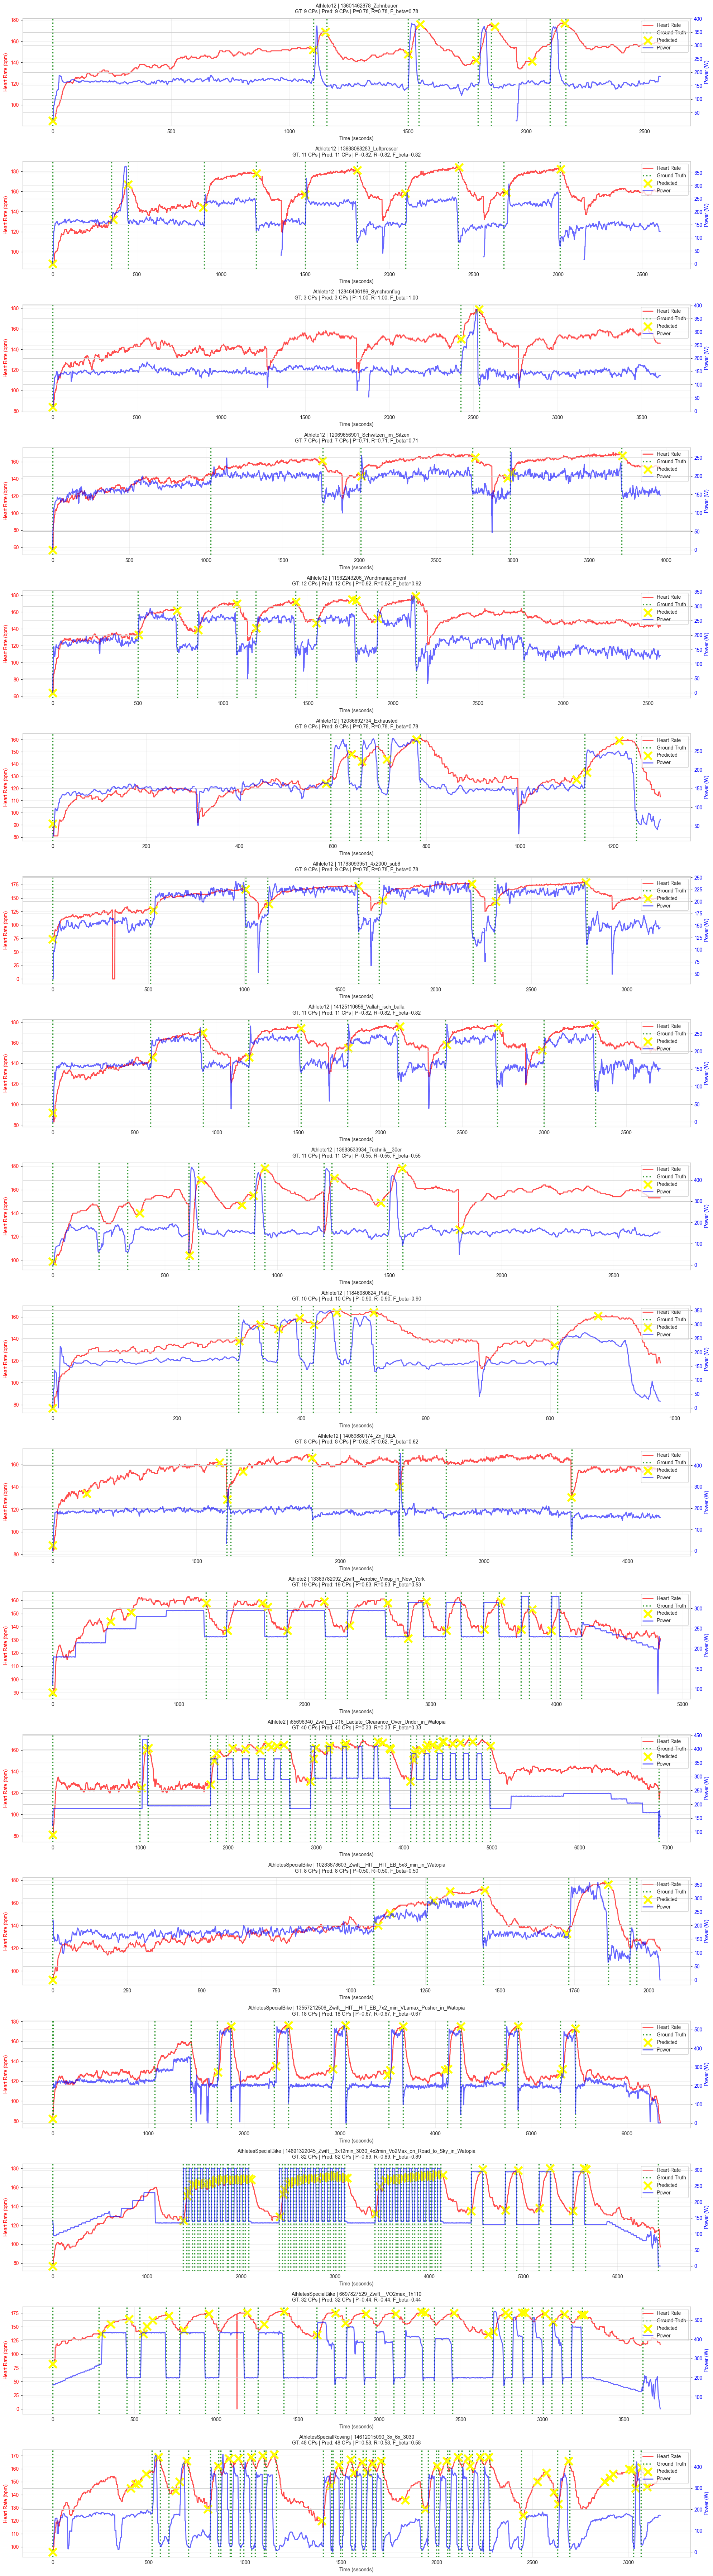

In [12]:
# Create subplots for all test sessions
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, result in enumerate(test_results):
    df = result['df']
    y_true = result['y_true']
    y_pred = result['y_pred']
    
    hr_values = df['heart_rate'].values
    
    # Create twin axis for power
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Plot heart rate on left axis (RED)
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power on right axis (BLUE)
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    pred_cps = np.where(y_pred == 1)[0]

    # Mark ground truth change points with GREEN vertical dotted lines
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                       alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark predicted change points with YELLOW X
    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                       linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

    # Set title with session info and metrics
    ax1.set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Summary Statistics


✓ Created df_results with 18 test sessions
   Sports breakdown:
     rowing: 12 sessions
     biking: 6 sessions

📊 Preview of df_results:
     athlete                          session   sport  n_intervals    f_beta  \
0  Athlete12            13601462878_Zehnbauer  rowing            9  0.777778   
1  Athlete12          13688068283_Luftpresser  rowing           11  0.818182   
2  Athlete12         12846436186_Synchronflug  rowing            3  1.000000   
3  Athlete12  12069656901_Schwitzen_im_Sitzen  rowing            7  0.714286   
4  Athlete12       11962243206_Wundmanagement  rowing           12  0.916667   

   mean_error_sec  
0       13.000000  
1        4.272727  
2        1.333333  
3        7.571429  
4        4.000000  


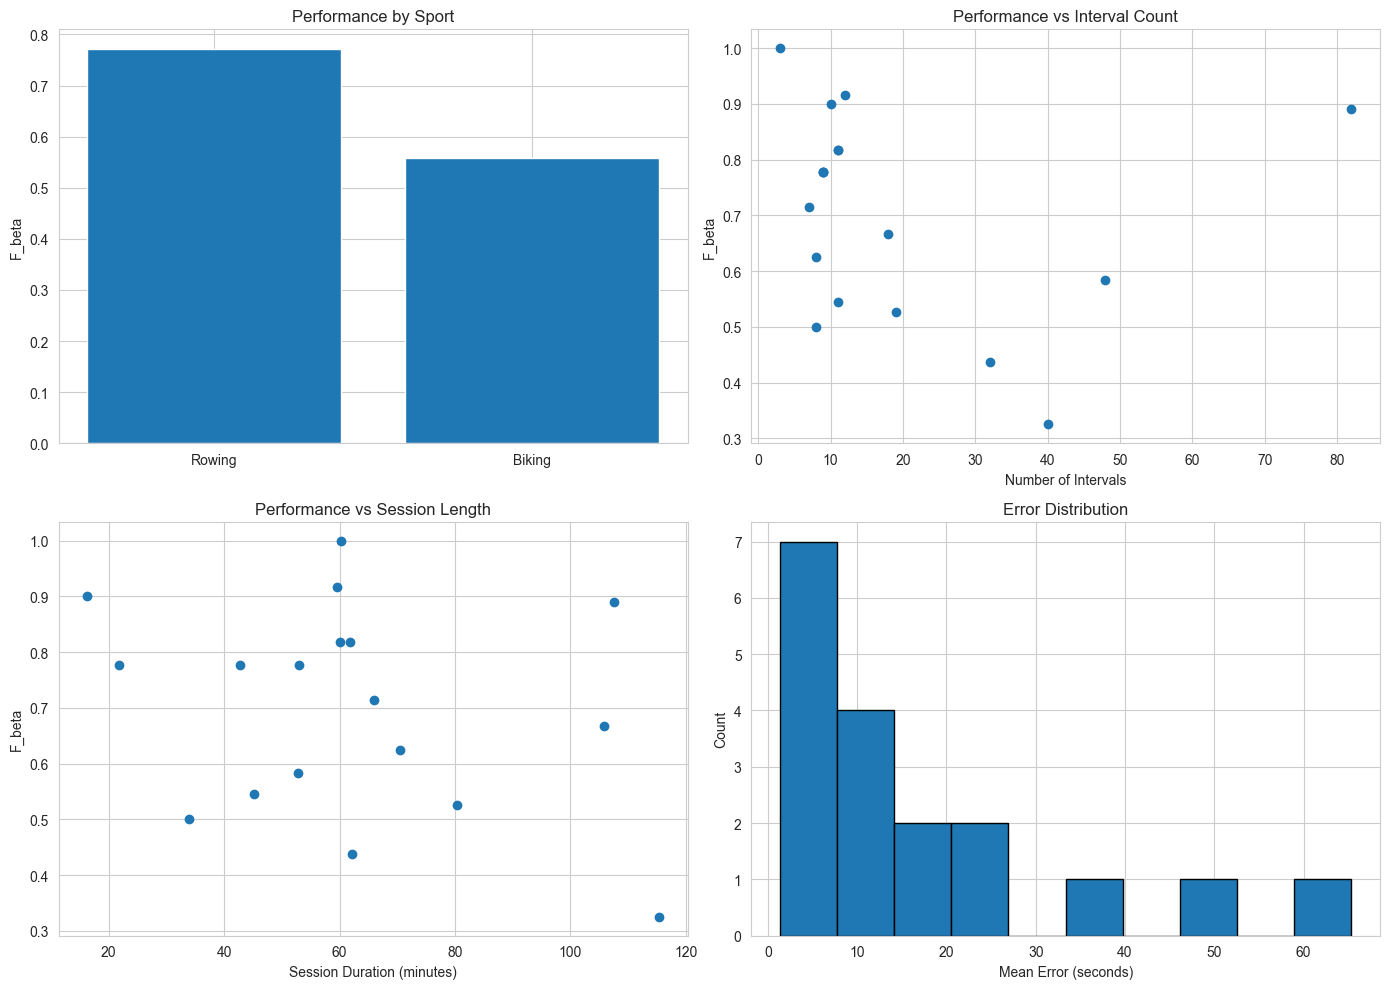

In [13]:
import matplotlib.pyplot as plt
# Create df_results from test_results
import pandas as pd

# Create a mapping from athlete name to sport
athlete_sport_mapping = {
    athlete_name: athlete_data['sport']
    for athlete_name, athlete_data in athletes.items()
}

df_results = pd.DataFrame([
    {
        'athlete': r['athlete'],
        'session': r['session'],
        'n_intervals': r['n_true'],
        'n_pred': r['n_pred'],
        'f_beta': r['f_beta'],
        'precision': r['precision'],
        'recall': r['recall'],
        'mean_error_sec': r['mean_error_sec'],
        'duration_sec': len(r['y_true']),
        'duration_min': len(r['y_true']) / 60,
        'sport': athlete_sport_mapping.get(r['athlete'], 'unknown')
    }
    for r in test_results
])

print(f"\n✓ Created df_results with {len(df_results)} test sessions")
print(f"   Sports breakdown:")
for sport, count in df_results['sport'].value_counts().items():
    print(f"     {sport}: {count} sessions")

print(f"\n📊 Preview of df_results:")
print(df_results[['athlete', 'session', 'sport', 'n_intervals', 'f_beta', 'mean_error_sec']].head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. F_beta by sport
axes[0, 0].bar(['Rowing', 'Biking'],
               [df_results[df_results['sport']=='rowing']['f_beta'].mean(),
                df_results[df_results['sport']=='biking']['f_beta'].mean()])
axes[0, 0].set_ylabel('F_beta')
axes[0, 0].set_title('Performance by Sport')

# 2. F_beta vs number of intervals
axes[0, 1].scatter(df_results['n_intervals'], df_results['f_beta'])
axes[0, 1].set_xlabel('Number of Intervals')
axes[0, 1].set_ylabel('F_beta')
axes[0, 1].set_title('Performance vs Interval Count')

# 3. F_beta vs session duration
axes[1, 0].scatter(df_results['duration_min'], df_results['f_beta'])
axes[1, 0].set_xlabel('Session Duration (minutes)')
axes[1, 0].set_ylabel('F_beta')
axes[1, 0].set_title('Performance vs Session Length')

# 4. Error distribution
axes[1, 1].hist(df_results['mean_error_sec'], bins=10, edgecolor='black')
axes[1, 1].set_xlabel('Mean Error (seconds)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Error Distribution')

plt.tight_layout()
plt.show()

# Save Results

In [14]:
# Save XGBoost results
import pickle

xgboost_results = {
    'model_name': 'XGBoost',
    'results': test_results,  # Your list of dicts with f_beta, precision, recall per session
}

with open('results/xgboost_results.pkl', 'wb') as f:
    pickle.dump(xgboost_results, f)

print(f"✓ Saved {len(test_results)} XGBoost results")

✓ Saved 18 XGBoost results


In [15]:
test_results

[{'precision': 0.7777777777777778,
  'recall': 0.7777777777777778,
  'f_beta': np.float64(0.7777777777777778),
  'n_true': 9,
  'n_pred': 9,
  'mean_error_sec': np.float64(13.0),
  'session': '13601462878_Zehnbauer',
  'athlete': 'Athlete12',
  'y_true': array([1, 0, 0, ..., 0, 0, 0], shape=(2567,)),
  'y_pred': array([1, 0, 0, ..., 0, 0, 0], shape=(2567,)),
  'y_pred_proba': array([0.8973337, 0.8516075, 0.840293 , ..., 0.0112837, 0.0112837,
         0.0112837], shape=(2567,), dtype=float32),
  'df':                      timestamp  altitude  cadence  distance  \
  0    2025-02-11 17:37:14+00:00       0.0      0.0       0.0   
  1    2025-02-11 17:37:15+00:00       0.0      0.0       2.8   
  2    2025-02-11 17:37:16+00:00       NaN      NaN       NaN   
  3    2025-02-11 17:37:17+00:00       NaN      NaN       NaN   
  4    2025-02-11 17:37:18+00:00       0.0     19.0      11.9   
  ...                        ...       ...      ...       ...   
  2562 2025-02-11 18:19:56+00:00       Na

# Feature Importance Vis


🔝 Top 20 Most Important Features:
Feature                                       Importance   Cumulative  
------------------------------------------------------------------------
expected_interval_length                      0.1016       0.1016      
intervals_per_minute                          0.0975       0.1991      
hr_increasing                                 0.0516       0.2507      
hr_vs_session_p25                             0.0479       0.2986      
hr_vs_session_p75                             0.0415       0.3400      
hr_change_past_to_future_normalized           0.0364       0.3764      
hr_vs_long_baseline                           0.0361       0.4125      
is_high_density_session                       0.0344       0.4469      
hr_lead_30s                                   0.0292       0.4761      
hr_pct_of_session_range                       0.0254       0.5014      
hr_change_from_lag60                          0.0243       0.5258      
hr_pct_of_session_max       

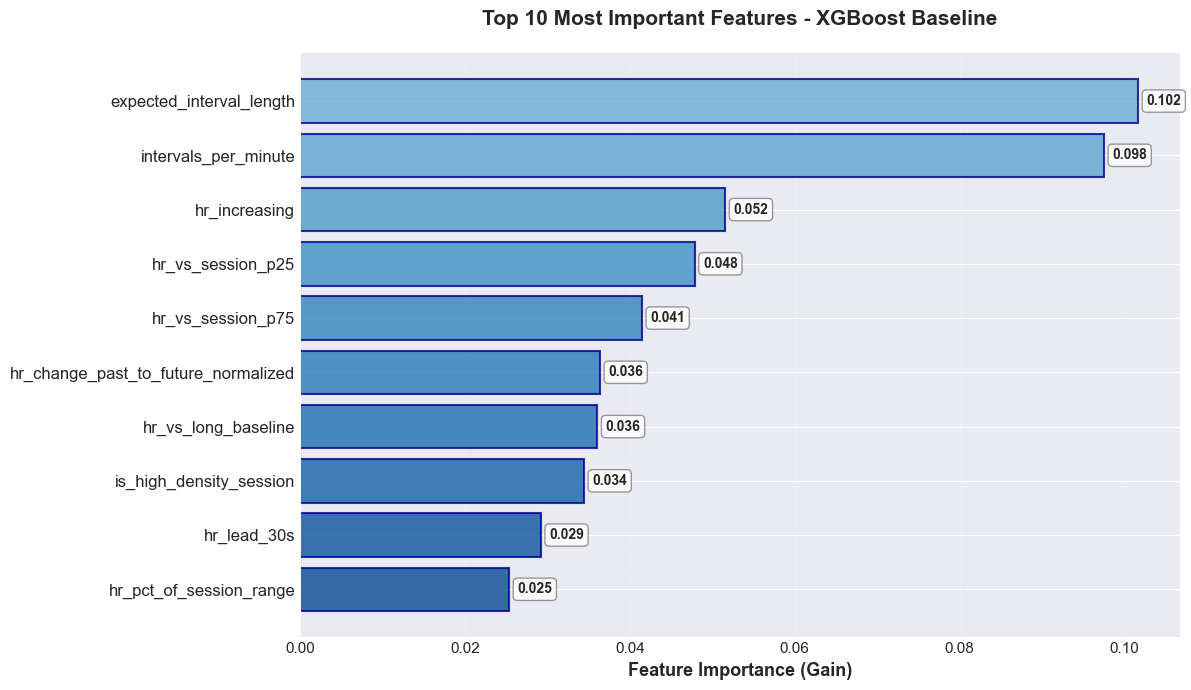


✅ Figure saved as 'xgboost_feature_importance_top10.png'

ALL 39 FEATURES RANKED BY IMPORTANCE

Rank   Feature                                       Importance   Cumulative  
--------------------------------------------------------------------------------
1      expected_interval_length                      0.1016       0.1016      
2      intervals_per_minute                          0.0975       0.1991      
3      hr_increasing                                 0.0516       0.2507      
4      hr_vs_session_p25                             0.0479       0.2986      
5      hr_vs_session_p75                             0.0415       0.3400      
6      hr_change_past_to_future_normalized           0.0364       0.3764      
7      hr_vs_long_baseline                           0.0361       0.4125      
8      is_high_density_session                       0.0344       0.4469      
9      hr_lead_30s                                   0.0292       0.4761      
10     hr_pct_of_session_range  

In [16]:
# %% Feature Importance Analysis - Improved Visualization

if hasattr(model, 'feature_importances_'):
    feature_names = train_sessions[0]['feature_names']
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    # Add cumulative importance
    importance_df['cumulative_importance'] = importance_df['importance'].cumsum()

    print("\n🔝 Top 20 Most Important Features:")
    print(f"{'Feature':<45} {'Importance':<12} {'Cumulative':<12}")
    print("-" * 72)
    for idx, row in importance_df.head(20).iterrows():
        print(f"{row['feature']:<45} {row['importance']:<12.4f} {row['cumulative_importance']:<12.4f}")

    # Summary statistics
    features_80 = len(importance_df[importance_df['cumulative_importance'] <= 0.80])
    features_90 = len(importance_df[importance_df['cumulative_importance'] <= 0.90])
    features_95 = len(importance_df[importance_df['cumulative_importance'] <= 0.95])

    print(f"\n📊 Feature Contribution Analysis:")
    print(f"   Total features: {len(feature_names)}")
    print(f"   Top 5 contribute: {importance_df.head(5)['importance'].sum():.1%}")
    print(f"   Top 10 contribute: {importance_df.head(10)['importance'].sum():.1%}")
    print(f"   Top 20 contribute: {importance_df.head(20)['importance'].sum():.1%}")
    print(f"   Features for 80% importance: {features_80}")
    print(f"   Features for 90% importance: {features_90}")
    print(f"   Features for 95% importance: {features_95}")

    # Identify near-zero importance features
    zero_importance = importance_df[importance_df['importance'] < 0.001]
    if len(zero_importance) > 0:
        print(f"\n❌ Near-zero importance features ({len(zero_importance)}):")
        for idx, row in zero_importance.iterrows():
            print(f"   {row['feature']}")

    # ============================================================================
    # IMPROVED VISUALIZATION FOR THESIS - TOP 10 FEATURES
    # ============================================================================

    # Set style for better-looking plots
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Use seaborn style for cleaner look
    plt.style.use('seaborn-v0_8-darkgrid')

    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))

    # Get top 10 features
    n_features_to_show = 10
    top_features = importance_df.head(n_features_to_show)

    # Create color gradient - darker for more important features
    colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(top_features)))

    # Create horizontal bar chart
    bars = ax.barh(range(len(top_features)),
                   top_features['importance'],
                   color=colors,
                   edgecolor='darkblue',
                   linewidth=1.5,
                   alpha=0.8)

    # Customize y-axis
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=12, fontweight='medium')

    # Customize x-axis
    ax.set_xlabel('Feature Importance (Gain)', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', labelsize=11)

    # Title
    ax.set_title('Top 10 Most Important Features - XGBoost Baseline',
                 fontsize=15, fontweight='bold', pad=20)

    # Invert y-axis so most important is at top
    ax.invert_yaxis()

    # Add grid for better readability
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)

    # Add importance values as text labels on bars
    for i, (bar, importance_val) in enumerate(zip(bars, top_features['importance'])):
        # Position text at end of bar
        ax.text(importance_val + 0.001, i, f'{importance_val:.3f}',
                va='center', ha='left', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor='gray', alpha=0.8))

    # Add legend
    ax.legend(loc='lower right', fontsize=11, framealpha=0.95,
             edgecolor='black', fancybox=True)

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Save with high quality
    plt.savefig('xgboost_feature_importance_top10.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

    print(f"\n✅ Figure saved as 'xgboost_feature_importance_top10.png'")

    # ============================================================================
    # DETAILED FEATURE TABLE (ALL FEATURES)
    # ============================================================================

    print(f"\n{'='*80}")
    print(f"ALL {len(feature_names)} FEATURES RANKED BY IMPORTANCE")
    print(f"{'='*80}\n")

    print(f"{'Rank':<6} {'Feature':<45} {'Importance':<12} {'Cumulative':<12}")
    print("-" * 80)

    for rank, (idx, row) in enumerate(importance_df.iterrows(), 1):
        print(f"{rank:<6} {row['feature']:<45} {row['importance']:<12.4f} {row['cumulative_importance']:<12.4f}")

    print(f"\n{'='*80}\n")

else:
    print("⚠️ Model does not have feature_importances_ attribute")